In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/sapnasamariya/malviznet/__results__.html
/kaggle/input/notebooks/sapnasamariya/malviznet/__notebook__.ipynb
/kaggle/input/notebooks/sapnasamariya/malviznet/malimg.npz
/kaggle/input/notebooks/sapnasamariya/malviznet/__output__.json
/kaggle/input/notebooks/sapnasamariya/malviznet/custom.css
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M9_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M10_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M8_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M4_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M1_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M2_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M7_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M6_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M5_history.json
/kaggle/input/notebooks/sapnasamariya

In [2]:
!wget -q https://raw.githubusercontent.com/Hydrogenion/Malimg/master/malimg.npz -O malimg.npz
!ls -lh malimg.npz

-rw-r--r-- 1 root root 14M Aug 15 12:53 malimg.npz


In [3]:
data = np.load('malimg.npz', allow_pickle=True)
arr = data['arr']
print(type(arr), arr.shape, arr.dtype)


<class 'numpy.ndarray'> (9339, 2) object


In [4]:
images_raw = arr[:, 0]
labels_raw = arr[:, 1]

print(type(images_raw[0]), images_raw[0].shape if hasattr(images_raw[0], 'shape') else images_raw[0])
print(labels_raw[0], type(labels_raw[0]))
print(np.unique(labels_raw).shape)  # should be 25

<class 'numpy.ndarray'> (32, 32)
0 <class 'int'>
(25,)


In [5]:
images = np.stack(images_raw).astype(np.uint8)
labels = labels_raw.astype(np.int64)

print(images.shape, images.dtype)
print(labels.shape, labels.dtype)

(9339, 32, 32) uint8
(9339,) int64


In [6]:
import cv2

images_resized = np.stack([
    cv2.resize(img, (128, 128), interpolation=cv2.INTER_CUBIC)
    for img in images
]).astype(np.float32)

print(images_resized.shape, images_resized.dtype)
print(images_resized.min(), images_resized.max())

(9339, 128, 128) float32
0.0 255.0


In [7]:
images_norm = images_resized / 255.0

print(images_norm.dtype, images_norm.min(), images_norm.max())

float32 0.0 1.0


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images_norm, labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

print(X_train.shape, X_test.shape)
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

(6537, 128, 128) (2802, 128, 128)
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24]), array([  85,   81, 2064, 1114,  139,   74,  140,  102,  124,  113,  267,
        302,  149,  129,   86,  111,   95,   99,  111,   56,   90,   92,
        286,   68,  560]))
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24]), array([ 37,  35, 885, 477,  59,  32,  60,  44,  53,  49, 114, 129,  64,
        55,  37,  48,  41,  43,  47,  24,  38,  40, 122,  29, 240]))


In [9]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print(class_weight_dict)

{0: np.float64(3.076235294117647), 1: np.float64(3.228148148148148), 2: np.float64(0.1266860465116279), 3: np.float64(0.23472172351885098), 4: np.float64(1.8811510791366906), 5: np.float64(3.5335135135135136), 6: np.float64(1.8677142857142857), 7: np.float64(2.563529411764706), 8: np.float64(2.108709677419355), 9: np.float64(2.313982300884956), 10: np.float64(0.9793258426966293), 11: np.float64(0.8658278145695364), 12: np.float64(1.7548993288590604), 13: np.float64(2.0269767441860465), 14: np.float64(3.0404651162790697), 15: np.float64(2.3556756756756756), 16: np.float64(2.752421052631579), 17: np.float64(2.641212121212121), 18: np.float64(2.3556756756756756), 19: np.float64(4.6692857142857145), 20: np.float64(2.9053333333333335), 21: np.float64(2.8421739130434784), 22: np.float64(0.9142657342657343), 23: np.float64(3.8452941176470588), 24: np.float64(0.4669285714285714)}


In [10]:
import tensorflow as tf

def augment(image, label):
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.02)
    image = image + noise
    image = tf.image.random_crop(
        tf.image.resize_with_pad(image, 140, 140), size=[128, 128, 1]
    )
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

In [11]:
BATCH_SIZE = 32

X_train_ch = X_train[..., np.newaxis]  # (N,128,128) -> (N,128,128,1)
X_test_ch = X_test[..., np.newaxis]

train_ds = tf.data.Dataset.from_tensor_slices((X_train_ch, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train_ch), seed=42)
train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_ch, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

for imgs, lbls in train_ds.take(1):
    print(imgs.shape, imgs.dtype, lbls.shape)
    print(imgs.numpy().min(), imgs.numpy().max())

I0000 00:00:1786798438.196486      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786798438.199329      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


(32, 128, 128, 1) <dtype: 'float32'> (32,)
0.0 1.0


In [12]:
from tensorflow.keras import layers, models

NUM_CLASSES = 25
INPUT_SHAPE = (128, 128, 1)

def compile_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def build_M1(lr=0.000075):
    m = models.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M1')
    return compile_model(m, lr)

m1 = build_M1()
m1.summary()

Model: "M1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,790,137 (64.05 MB)

 Trainable params: 16,790,137 (64.05 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
def build_M2(lr=0.00001):
    m = models.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M2')
    return compile_model(m, lr)

m2 = build_M2()
m2.summary()

Model: "M2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,780,889 (64.01 MB)

 Trainable params: 16,780,889 (64.01 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
def build_M3(lr=0.01):
    m = models.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M3')
    return compile_model(m, lr)

m3 = build_M3()
m3.summary()

Model: "M3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,799,385 (64.08 MB)

 Trainable params: 16,799,385 (64.08 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
def build_M4(lr=0.01):
    m = models.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M4')
    return compile_model(m, lr)

m4 = build_M4()
m4.summary()

Model: "M4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,790,137 (64.05 MB)

 Trainable params: 16,790,137 (64.05 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
def build_M5(lr=0.01):
    m = models.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.GlobalMaxPooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M5')
    return compile_model(m, lr)

m5 = build_M5()
m5.summary()

Model: "M5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,769 (30.35 KB)

 Trainable params: 7,769 (30.35 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
def build_M6(lr=0.01):
    m = models.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.GlobalMaxPooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M6')
    return compile_model(m, lr)

m6 = build_M6()
m6.summary()

Model: "M6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_1          │ (None, 32)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,017 (66.47 KB)

 Trainable params: 17,017 (66.47 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
def build_M7(lr=0.01):
    m = models.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M7')
    return compile_model(m, lr)

m7 = build_M7()
m7.summary()

Model: "M7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,207,225 (16.05 MB)

 Trainable params: 4,207,225 (16.05 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
def build_M8(lr=0.01):
    m = models.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M8')
    return compile_model(m, lr)

m8 = build_M8()
m8.summary()

Model: "M8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,070,745 (4.08 MB)

 Trainable params: 1,070,745 (4.08 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
import time
import json
import os

os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/history', exist_ok=True)

def train_model(model, train_ds, test_ds, epochs, class_weight_dict, model_name):
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            f'/kaggle/working/checkpoints/{model_name}_best.keras',
            monitor='val_accuracy', save_best_only=True, mode='max'
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=15, restore_best_weights=True, mode='max'
        )
    ]

    start = time.time()
    history = model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=epochs,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )
    train_time = time.time() - start

    with open(f'/kaggle/working/history/{model_name}_history.json', 'w') as f:
        json.dump({
            'history': history.history,
            'train_time_sec': train_time,
            'epochs_run': len(history.history['loss'])
        }, f)

    return history, train_time

# Test run on M-1
history_m1, time_m1 = train_model(
    m1, train_ds, test_ds, epochs=50,
    class_weight_dict=class_weight_dict, model_name='M1'
)
print(f"M-1 training time: {time_m1:.1f}s")

Epoch 1/50


2026-08-15 12:54:07.149792: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 12:54:07.444370: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  7/205 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.0094 - loss: 3.1555

I0000 00:00:1786798449.422920      69 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


202/205 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0194 - loss: 3.2073

2026-08-15 12:54:14.765356: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 12:54:15.063665: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 12:54:15.269273: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv (f32[9,32,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[9,32,128,128]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"

205/205 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.0291 - loss: 3.1766 - val_accuracy: 0.0478 - val_loss: 3.1605
Epoch 2/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.0808 - loss: 3.0091 - val_accuracy: 0.3180 - val_loss: 2.8798
Epoch 3/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.1897 - loss: 2.5767 - val_accuracy: 0.2384 - val_loss: 2.4547
Epoch 4/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.2844 - loss: 2.0196 - val_accuracy: 0.4729 - val_loss: 2.0225
Epoch 5/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.3668 - loss: 1.6307 - val_accuracy: 0.5542 - val_loss: 1.4668
Epoch 6/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4013 - loss: 1.4309 - val_accuracy: 0.4668 - val_loss: 1.5660
Epoch 7/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4283 - loss: 1.3335 - val_accuracy: 0.4814 - val_loss: 1.5700
Epoch 8/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4459 - loss: 1.2175 - val_accuracy: 0.37

In [21]:
history_m2, time_m2 = train_model(
    m2, train_ds, test_ds, epochs=50,
    class_weight_dict=class_weight_dict, model_name='M2'
)
print(f"M-2 training time: {time_m2:.1f}s")


Epoch 1/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.0274 - loss: 3.1982 - val_accuracy: 0.0303 - val_loss: 3.1510
Epoch 2/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0280 - loss: 3.1488 - val_accuracy: 0.0310 - val_loss: 3.1263
Epoch 3/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0359 - loss: 3.0997 - val_accuracy: 0.0418 - val_loss: 3.0744
Epoch 4/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0558 - loss: 3.0547 - val_accuracy: 0.0867 - val_loss: 3.0619
Epoch 5/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1135 - loss: 3.0067 - val_accuracy: 0.0582 - val_loss: 3.0187
Epoch 6/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1189 - loss: 2.9534 - val_accuracy: 0.2070 - val_loss: 2.9761
Epoch 7/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1565 - loss: 2.9055 - val_accuracy: 0.2095 - val_loss: 2.9091
Epoch 8/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1508 - loss: 2.8527 - val_accu

In [22]:
history_m3, time_m3 = train_model(
    m3, train_ds, test_ds, epochs=200,
    class_weight_dict=class_weight_dict, model_name='M3'
)
print(f"M-3 training time: {time_m3:.1f}s")

Epoch 1/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.1401 - loss: 2.8233 - val_accuracy: 0.3169 - val_loss: 2.4885
Epoch 2/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.3131 - loss: 1.7426 - val_accuracy: 0.3137 - val_loss: 2.0777
Epoch 3/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.3492 - loss: 1.4660 - val_accuracy: 0.3876 - val_loss: 1.6407
Epoch 4/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.3197 - loss: 1.7080 - val_accuracy: 0.2909 - val_loss: 1.7660
Epoch 5/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.4026 - loss: 1.1963 - val_accuracy: 0.5007 - val_loss: 1.2388
Epoch 6/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.4279 - loss: 1.0508 - val_accuracy: 0.3576 - val_loss: 1.4360
Epoch 7/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.4626 - loss: 0.8785 - val_accuracy: 0.4879 - val_loss: 1.2167
Epoch 8/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.4635 - loss: 0.8201 -

In [23]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = np.argmax(m3.predict(X_test_ch), axis=1)
print(classification_report(y_test, y_pred, zero_division=0))

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        37
           1       1.00      1.00      1.00        35
           2       0.88      0.59      0.70       885
           3       0.58      0.93      0.71       477
           4       0.82      0.98      0.89        59
           5       1.00      1.00      1.00        32
           6       0.55      0.28      0.37        60
           7       0.41      0.70      0.52        44
           8       0.95      0.98      0.96        53
           9       1.00      1.00      1.00        49
          10       0.97      0.97      0.97       114
          11       0.98      0.99      0.99       129
          12       0.98      0.91      0.94        64
          13       1.00      0.98      0.99        55
          14       1.00      1.00      1.00        37
          15       0.96      0.90      0.92        48
          16       0.67      0.34      0.

In [24]:
history_m4, time_m4 = train_model(
    m4, train_ds, test_ds, epochs=120,
    class_weight_dict=class_weight_dict, model_name='M4'
)
print(f"M-4 training time: {time_m4:.1f}s")

Epoch 1/120


2026-08-15 13:12:35.939680: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 13:12:36.082014: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


202/205 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1141 - loss: 2.8494

2026-08-15 13:12:40.268669: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 13:12:40.408250: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


205/205 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.2238 - loss: 2.2872 - val_accuracy: 0.3462 - val_loss: 1.9128
Epoch 2/120
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.3988 - loss: 1.3718 - val_accuracy: 0.5200 - val_loss: 1.0737
Epoch 3/120
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.4566 - loss: 0.9960 - val_accuracy: 0.5617 - val_loss: 1.0577
Epoch 4/120
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.4955 - loss: 0.8270 - val_accuracy: 0.6906 - val_loss: 0.8963
Epoch 5/120
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5334 - loss: 0.7909 - val_accuracy: 0.5760 - val_loss: 1.0901
Epoch 6/120
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5447 - loss: 0.6709 - val_accuracy: 0.6545 - val_loss: 0.8142
Epoch 7/120
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5585 - loss: 0.6201 - val_accuracy: 0.5689 - val_loss: 1.0177
Epoch 8/120
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5804 - loss: 0.6154 - val_accuracy

In [25]:
history_m5, time_m5 = train_model(
    m5, train_ds, test_ds, epochs=50,
    class_weight_dict=class_weight_dict, model_name='M5'
)
print(f"M-5 training time: {time_m5:.1f}s")

Epoch 1/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.0231 - loss: 3.2213 - val_accuracy: 0.0218 - val_loss: 3.2119
Epoch 2/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0317 - loss: 3.1724 - val_accuracy: 0.0468 - val_loss: 3.0940
Epoch 3/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0494 - loss: 2.9707 - val_accuracy: 0.0257 - val_loss: 3.0008
Epoch 4/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0630 - loss: 2.7926 - val_accuracy: 0.1203 - val_loss: 2.8252
Epoch 5/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0821 - loss: 2.7047 - val_accuracy: 0.0325 - val_loss: 2.9298
Epoch 6/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0780 - loss: 2.6696 - val_accuracy: 0.0403 - val_loss: 2.8907
Epoch 7/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0823 - loss: 2.6652 - val_accuracy: 0.0400 - val_loss: 2.8286
Epoch 8/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0809 - loss: 2.6140 - val_accuracy: 

In [26]:
history_m6, time_m6 = train_model(
    m6, train_ds, test_ds, epochs=50,
    class_weight_dict=class_weight_dict, model_name='M6'
)
print(f"M-6 training time: {time_m6:.1f}s")

Epoch 1/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.0389 - loss: 3.2191 - val_accuracy: 0.0228 - val_loss: 3.1972
Epoch 2/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.1031 - loss: 3.0400 - val_accuracy: 0.1271 - val_loss: 2.8754
Epoch 3/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.0779 - loss: 2.7209 - val_accuracy: 0.0578 - val_loss: 2.8808
Epoch 4/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.0779 - loss: 2.6758 - val_accuracy: 0.0714 - val_loss: 2.8470
Epoch 5/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.0837 - loss: 2.6173 - val_accuracy: 0.0471 - val_loss: 2.7975
Epoch 6/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.0921 - loss: 2.6124 - val_accuracy: 0.1388 - val_loss: 2.8897
Epoch 7/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.1130 - loss: 2.5509 - val_accuracy: 0.0389 - val_loss: 3.1999
Epoch 8/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.1198 - loss: 2.4639 - val_accu

In [27]:
history_m7, time_m7 = train_model(
    m7, train_ds, test_ds, epochs=250,
    class_weight_dict=class_weight_dict, model_name='M7'
)
print(f"M-7 training time: {time_m7:.1f}s")

Epoch 1/250
205/205 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.2137 - loss: 2.3759 - val_accuracy: 0.4033 - val_loss: 1.8885
Epoch 2/250
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3976 - loss: 1.2583 - val_accuracy: 0.2994 - val_loss: 2.1365
Epoch 3/250
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4545 - loss: 0.9886 - val_accuracy: 0.5382 - val_loss: 1.2967
Epoch 4/250
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4754 - loss: 0.8524 - val_accuracy: 0.4168 - val_loss: 1.2811
Epoch 5/250
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5299 - loss: 0.7433 - val_accuracy: 0.6399 - val_loss: 0.9804
Epoch 6/250
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5473 - loss: 0.6528 - val_accuracy: 0.5325 - val_loss: 1.0442
Epoch 7/250
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5568 - loss: 0.6248 - val_accuracy: 0.5542 - val_loss: 1.0110
Epoch 8/250
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5750 - loss: 0.5844 - 

In [28]:
history_m8, time_m8 = train_model(
    m8, train_ds, test_ds, epochs=200,
    class_weight_dict=class_weight_dict, model_name='M8'
)
print(f"M-8 training time: {time_m8:.1f}s")

Epoch 1/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.1686 - loss: 2.5850 - val_accuracy: 0.4657 - val_loss: 1.5018
Epoch 2/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4063 - loss: 1.3216 - val_accuracy: 0.3758 - val_loss: 1.6598
Epoch 3/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4692 - loss: 0.9994 - val_accuracy: 0.4818 - val_loss: 1.2912
Epoch 4/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5209 - loss: 0.8320 - val_accuracy: 0.6292 - val_loss: 1.0285
Epoch 5/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5425 - loss: 0.6956 - val_accuracy: 0.5867 - val_loss: 0.9729
Epoch 6/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5651 - loss: 0.6409 - val_accuracy: 0.6610 - val_loss: 0.8050
Epoch 7/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6117 - loss: 0.5436 - val_accuracy: 0.5271 - val_loss: 0.9861
Epoch 8/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6243 - loss: 0.5141 - 

In [29]:
def build_M9(lr=0.0001):
    m = models.Sequential([
        layers.Input(INPUT_SHAPE),
        # Stage 1
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        # Stage 2
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        # Stage 3
        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dense(2048, activation='relu'),
        layers.Dense(1024, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M9')
    return compile_model(m, lr)

m9 = build_M9()
m9.summary()

Model: "M9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4096)           │   268,439,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2048)           │     8,390,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 25)             │        25,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 280,098,265 (1.04 GB)

 Trainable params: 280,098,265 (1.04 GB)

 Non-trainable params: 0 (0.00 B)

In [30]:
def build_M9(lr=0.0001):
    m = models.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M9')
    return compile_model(m, lr)

m9 = build_M9()
m9.summary()

Model: "M9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,443,289 (5.51 MB)

 Trainable params: 1,443,289 (5.51 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_m9, time_m9 = train_model(
    m9, train_ds, test_ds, epochs=30,
    class_weight_dict=class_weight_dict, model_name='M9'
)
print(f"M-9 training time: {time_m9:.1f}s")

Epoch 1/30


2026-08-15 13:24:33.041605: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 13:24:33.245182: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 13:24:34.271442: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 13:24:34.451380: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 13:24:36.394934: E external/local_xla/xla/stream_

204/205 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.0306 - loss: 3.2285

2026-08-15 13:25:06.976612: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 13:25:07.166996: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 13:25:07.546932: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 13:25:07.712769: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 13:25:08.566901: E external/local_xla/xla/stream_

205/205 ━━━━━━━━━━━━━━━━━━━━ 58s 193ms/step - accuracy: 0.0277 - loss: 3.2189 - val_accuracy: 0.0446 - val_loss: 3.2207
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.0468 - loss: 3.2189 - val_accuracy: 0.0435 - val_loss: 3.2205
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - accuracy: 0.0459 - loss: 3.2188 - val_accuracy: 0.0435 - val_loss: 3.2204
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 111ms/step - accuracy: 0.0444 - loss: 3.2188 - val_accuracy: 0.0539 - val_loss: 3.2205
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - accuracy: 0.0456 - loss: 3.2187 - val_accuracy: 0.0435 - val_loss: 3.2203
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - accuracy: 0.0436 - loss: 3.2186 - val_accuracy: 0.0435 - val_loss: 3.2203
Epoch 7/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - accuracy: 0.0438 - loss: 3.2186 - val_accuracy: 0.0435 - val_loss: 3.2201
Epoch 8/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - accuracy: 0.0438 - loss: 3.2186 - val

In [32]:
def compile_model_adam(model, lr=0.001):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def build_M9(lr=0.001):
    m = models.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M9')
    return compile_model_adam(m, lr)

m9 = build_M9()
m9.summary()

Model: "M9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,443,289 (5.51 MB)

 Trainable params: 1,443,289 (5.51 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/notebooks/sapnasamariya/malviznet/__results__.html
/kaggle/input/notebooks/sapnasamariya/malviznet/__notebook__.ipynb
/kaggle/input/notebooks/sapnasamariya/malviznet/malimg.npz
/kaggle/input/notebooks/sapnasamariya/malviznet/__output__.json
/kaggle/input/notebooks/sapnasamariya/malviznet/custom.css
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M9_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M10_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M8_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M4_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M1_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M2_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M7_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M6_history.json
/kaggle/input/notebooks/sapnasamariya/malviznet/history/M5_history.json
/kaggle/input/notebooks/sapnasamariya

In [34]:
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import time, json, os

INPUT_BASE = '/kaggle/input/notebooks/sapnasamariya/malviznet'

# Load npz from attached input (no re-download needed)
data = np.load(f'{INPUT_BASE}/malimg.npz', allow_pickle=True)
arr = data['arr']
images_raw = arr[:, 0]
labels_raw = arr[:, 1]
images = np.stack(images_raw).astype(np.uint8)
labels = labels_raw.astype(np.int64)

images_resized = np.stack([
    cv2.resize(img, (128, 128), interpolation=cv2.INTER_CUBIC)
    for img in images
]).astype(np.float32)
images_norm = images_resized / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    images_norm, labels, test_size=0.30, stratify=labels, random_state=42
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

def augment(image, label):
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.02)
    image = image + noise
    image = tf.image.random_crop(
        tf.image.resize_with_pad(image, 140, 140), size=[128, 128, 1]
    )
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

BATCH_SIZE = 32
X_train_ch = X_train[..., np.newaxis]
X_test_ch = X_test[..., np.newaxis]

train_ds = tf.data.Dataset.from_tensor_slices((X_train_ch, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train_ch), seed=42)
train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_ch, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

NUM_CLASSES = 25
INPUT_SHAPE = (128, 128, 1)

def compile_model(model, lr):
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def compile_model_adam(model, lr=0.001):
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/history', exist_ok=True)

def train_model(model, train_ds, test_ds, epochs, class_weight_dict, model_name):
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(f'/kaggle/working/checkpoints/{model_name}_best.keras',
                                            monitor='val_accuracy', save_best_only=True, mode='max'),
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15,
                                          restore_best_weights=True, mode='max')
    ]
    start = time.time()
    history = model.fit(train_ds, validation_data=test_ds, epochs=epochs,
                         class_weight=class_weight_dict, callbacks=callbacks, verbose=1)
    train_time = time.time() - start
    with open(f'/kaggle/working/history/{model_name}_history.json', 'w') as f:
        json.dump({'history': history.history, 'train_time_sec': train_time,
                   'epochs_run': len(history.history['loss'])}, f)
    return history, train_time

# Load-or-train guard for M-1 to M-8
trained_models = {}
histories = {}
for name in ['M1','M2','M3','M4','M5','M6','M7','M8']:
    ckpt_path = f'{INPUT_BASE}/checkpoints/{name}_best.keras'
    hist_path = f'{INPUT_BASE}/history/{name}_history.json'
    if os.path.exists(ckpt_path):
        trained_models[name] = tf.keras.models.load_model(ckpt_path)
        with open(hist_path) as f:
            histories[name] = json.load(f)
        print(f"{name}: loaded from input (val_acc best={max(histories[name]['history']['val_accuracy']):.4f})")
    else:
        print(f"{name}: NOT found, needs training")

print("\nPipeline restored:", X_train.shape, X_test.shape)

M1: loaded from input (val_acc best=0.6874)
M2: loaded from input (val_acc best=0.4964)
M3: loaded from input (val_acc best=0.7330)
M4: loaded from input (val_acc best=0.8248)
M5: loaded from input (val_acc best=0.1792)
M6: loaded from input (val_acc best=0.2034)
M7: loaded from input (val_acc best=0.8205)
M8: loaded from input (val_acc best=0.7866)

Pipeline restored: (6537, 128, 128) (2802, 128, 128)


In [35]:
import numpy as np 
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import time, json, os, shutil

INPUT_BASE = '/kaggle/input/notebooks/sapnasamariya/malviznet'

data = np.load(f'{INPUT_BASE}/malimg.npz', allow_pickle=True)
arr = data['arr']
images_raw = arr[:, 0]
labels_raw = arr[:, 1]
images = np.stack(images_raw).astype(np.uint8)
labels = labels_raw.astype(np.int64)

images_resized = np.stack([
    cv2.resize(img, (128, 128), interpolation=cv2.INTER_CUBIC)
    for img in images
]).astype(np.float32)
images_norm = images_resized / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    images_norm, labels, test_size=0.30, stratify=labels, random_state=42
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

def augment(image, label):
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.02)
    image = image + noise
    image = tf.image.random_crop(
        tf.image.resize_with_pad(image, 140, 140), size=[128, 128, 1]
    )
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

BATCH_SIZE = 32
X_train_ch = X_train[..., np.newaxis]
X_test_ch = X_test[..., np.newaxis]

train_ds = tf.data.Dataset.from_tensor_slices((X_train_ch, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train_ch), seed=42)
train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_ch, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

NUM_CLASSES = 25
INPUT_SHAPE = (128, 128, 1)

def compile_model(model, lr):
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def compile_model_adam(model, lr=0.001):
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/history', exist_ok=True)

def train_model(model, train_ds, test_ds, epochs, class_weight_dict, model_name):
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(f'/kaggle/working/checkpoints/{model_name}_best.keras',
                                            monitor='val_accuracy', save_best_only=True, mode='max'),
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15,
                                          restore_best_weights=True, mode='max')
    ]
    start = time.time()
    history = model.fit(train_ds, validation_data=test_ds, epochs=epochs,
                         class_weight=class_weight_dict, callbacks=callbacks, verbose=1)
    train_time = time.time() - start
    with open(f'/kaggle/working/history/{model_name}_history.json', 'w') as f:
        json.dump({'history': history.history, 'train_time_sec': train_time,
                   'epochs_run': len(history.history['loss'])}, f)
    return history, train_time

trained_models = {}
histories = {}
for name in ['M1','M2','M3','M4','M5','M6','M7','M8']:
    ckpt_path = f'{INPUT_BASE}/checkpoints/{name}_best.keras'
    hist_path = f'{INPUT_BASE}/history/{name}_history.json'
    if os.path.exists(ckpt_path):
        trained_models[name] = tf.keras.models.load_model(ckpt_path)
        with open(hist_path) as f:
            histories[name] = json.load(f)
        shutil.copy(ckpt_path, f'/kaggle/working/checkpoints/{name}_best.keras')
        shutil.copy(hist_path, f'/kaggle/working/history/{name}_history.json')
        print(f"{name}: loaded + copied forward (val_acc best={max(histories[name]['history']['val_accuracy']):.4f})")
    else:
        print(f"{name}: NOT found, needs training")

print("\nPipeline restored:", X_train.shape, X_test.shape)


M1: loaded + copied forward (val_acc best=0.6874)
M2: loaded + copied forward (val_acc best=0.4964)
M3: loaded + copied forward (val_acc best=0.7330)
M4: loaded + copied forward (val_acc best=0.8248)
M5: loaded + copied forward (val_acc best=0.1792)
M6: loaded + copied forward (val_acc best=0.2034)
M7: loaded + copied forward (val_acc best=0.8205)
M8: loaded + copied forward (val_acc best=0.7866)

Pipeline restored: (6537, 128, 128) (2802, 128, 128)


In [36]:
def build_M9(lr=0.001):
    m = models.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(128, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2),
        layers.Conv2D(256, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(256, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M9')
    return compile_model_adam(m, lr)

m9 = build_M9()
m9.summary()

Model: "M9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             

 Total params: 1,446,873 (5.52 MB)

 Trainable params: 1,445,081 (5.51 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [37]:
history_m9, time_m9 = train_model(
    m9, train_ds, test_ds, epochs=30,
    class_weight_dict=class_weight_dict, model_name='M9'
)
print(f"M-9 training time: {time_m9:.1f}s")

Epoch 1/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 42s 165ms/step - accuracy: 0.1967 - loss: 2.2433 - val_accuracy: 0.0253 - val_loss: 45.2619
Epoch 2/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 26s 127ms/step - accuracy: 0.3026 - loss: 1.5612 - val_accuracy: 0.0264 - val_loss: 11.6127
Epoch 3/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 25s 122ms/step - accuracy: 0.3534 - loss: 1.3694 - val_accuracy: 0.0924 - val_loss: 3.7369
Epoch 4/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - accuracy: 0.3913 - loss: 1.1869 - val_accuracy: 0.1681 - val_loss: 6.5072
Epoch 5/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 26s 125ms/step - accuracy: 0.4219 - loss: 1.0281 - val_accuracy: 0.3390 - val_loss: 1.8880
Epoch 6/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 25s 124ms/step - accuracy: 0.4594 - loss: 0.9714 - val_accuracy: 0.1845 - val_loss: 3.6849
Epoch 7/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - accuracy: 0.4765 - loss: 0.9105 - val_accuracy: 0.1292 - val_loss: 7.1016
Epoch 8/30
205/205 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - accuracy: 0.5079 - loss:

In [38]:
BATCH_SIZE = 64

train_ds = tf.data.Dataset.from_tensor_slices((X_train_ch, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train_ch), seed=42)
train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_ch, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

for imgs, lbls in train_ds.take(1):
    print(imgs.shape, imgs.dtype, lbls.shape)

(64, 128, 128, 1) <dtype: 'float32'> (64,)


In [39]:
m9 = build_M9()
history_m9, time_m9 = train_model(
    m9, train_ds, test_ds, epochs=30,
    class_weight_dict=class_weight_dict, model_name='M9'
)
print(f"M-9 training time: {time_m9:.1f}s")

Epoch 1/30


2026-08-15 13:48:33.521521: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 13:48:33.754066: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 13:48:35.462846: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 13:48:35.661558: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-15 13:48:38.628884: E external/local_xla/xla/stream_

103/103 ━━━━━━━━━━━━━━━━━━━━ 71s 370ms/step - accuracy: 0.1851 - loss: 2.2286 - val_accuracy: 0.0253 - val_loss: 45.1555
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 25s 242ms/step - accuracy: 0.2975 - loss: 1.6047 - val_accuracy: 0.0132 - val_loss: 40.2293
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 25s 244ms/step - accuracy: 0.3652 - loss: 1.2885 - val_accuracy: 0.0132 - val_loss: 44.4504
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 25s 247ms/step - accuracy: 0.4245 - loss: 1.0807 - val_accuracy: 0.0132 - val_loss: 30.0178
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 248ms/step - accuracy: 0.4597 - loss: 0.9806 - val_accuracy: 0.0161 - val_loss: 11.5914
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 248ms/step - accuracy: 0.4989 - loss: 0.8677 - val_accuracy: 0.1238 - val_loss: 8.3374
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 25s 247ms/step - accuracy: 0.5077 - loss: 0.7838 - val_accuracy: 0.1913 - val_loss: 3.4285
Epoch 8/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 25s 245ms/step - accuracy: 0.5125 - loss: 0.7998 

In [40]:
def build_M10(lr=0.001, dropout_rates=(0.2, 0.3, 0.4)):
    d1, d2, d3 = dropout_rates
    m = models.Sequential([
        layers.Input(INPUT_SHAPE),
        # Stage 1
        layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(d1),
        # Stage 2
        layers.Conv2D(128, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(128, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(d2),
        # Stage 3
        layers.Conv2D(256, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(256, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(d3),
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'), layers.Dropout(0.3),
        layers.Dense(256, activation='relu'), layers.Dropout(0.3),
        layers.Dense(128, activation='relu'), layers.Dropout(0.2),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M10')
    return compile_model_adam(m, lr)

m10 = build_M10()
m10.summary()

Model: "M10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_46 (Conv2D)              │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 32, 32, 256)    │             

 Total params: 1,446,873 (5.52 MB)

 Trainable params: 1,445,081 (5.51 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [41]:
history_m10, time_m10 = train_model(
    m10, train_ds, test_ds, epochs=30,
    class_weight_dict=class_weight_dict, model_name='M10'
)
print(f"M-10 training time: {time_m10:.1f}s")

Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 46s 332ms/step - accuracy: 0.1599 - loss: 2.7024 - val_accuracy: 0.0132 - val_loss: 34.0376
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 27s 259ms/step - accuracy: 0.2396 - loss: 2.0198 - val_accuracy: 0.0132 - val_loss: 72.5255
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 248ms/step - accuracy: 0.2792 - loss: 1.7246 - val_accuracy: 0.0264 - val_loss: 69.5968
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 25s 242ms/step - accuracy: 0.3234 - loss: 1.5204 - val_accuracy: 0.0253 - val_loss: 57.0901
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 250ms/step - accuracy: 0.3600 - loss: 1.3395 - val_accuracy: 0.0325 - val_loss: 32.9693
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 252ms/step - accuracy: 0.3806 - loss: 1.2519 - val_accuracy: 0.0889 - val_loss: 9.4170
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 251ms/step - accuracy: 0.3950 - loss: 1.2499 - val_accuracy: 0.1574 - val_loss: 7.2292
Epoch 8/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 247ms/step - accuracy: 0.4366 - lo

In [42]:
def build_M11(lr=0.001):
    m = build_M10.__wrapped__(lr, dropout_rates=(0.1, 0.2, 0.3)) if hasattr(build_M10, '__wrapped__') else None
    return m

# Simpler: redefine directly with new rates
def build_M11(lr=0.001):
    d1, d2, d3 = 0.1, 0.2, 0.3
    m = models.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(d1),
        layers.Conv2D(128, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(128, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(d2),
        layers.Conv2D(256, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(256, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(d3),
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'), layers.Dropout(0.2),
        layers.Dense(256, activation='relu'), layers.Dropout(0.2),
        layers.Dense(128, activation='relu'), layers.Dropout(0.1),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M11')
    return compile_model_adam(m, lr)

m11 = build_M11()
m11.summary()

Model: "M11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_52 (Conv2D)              │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 32, 32, 256)    │             

 Total params: 1,446,873 (5.52 MB)

 Trainable params: 1,445,081 (5.51 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [43]:
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import time, json, os, shutil, glob

INPUT_BASE = '/kaggle/input/notebooks/sapnasamariya/malviznet'

data = np.load(f'{INPUT_BASE}/malimg.npz', allow_pickle=True)
arr = data['arr']
images_raw = arr[:, 0]
labels_raw = arr[:, 1]
images = np.stack(images_raw).astype(np.uint8)
labels = labels_raw.astype(np.int64)

images_resized = np.stack([
    cv2.resize(img, (128, 128), interpolation=cv2.INTER_CUBIC)
    for img in images
]).astype(np.float32)
images_norm = images_resized / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    images_norm, labels, test_size=0.30, stratify=labels, random_state=42
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

def augment(image, label):
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.02)
    image = image + noise
    image = tf.image.random_crop(
        tf.image.resize_with_pad(image, 140, 140), size=[128, 128, 1]
    )
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

BATCH_SIZE = 64  # corrected: matches M-9/M-10/M-11 (BN-based models need larger batch for stable stats)
X_train_ch = X_train[..., np.newaxis]
X_test_ch = X_test[..., np.newaxis]

train_ds = tf.data.Dataset.from_tensor_slices((X_train_ch, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train_ch), seed=42)
train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_ch, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

NUM_CLASSES = 25
INPUT_SHAPE = (128, 128, 1)

def compile_model(model, lr):
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def compile_model_adam(model, lr=0.001):
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/history', exist_ok=True)

def train_model(model, train_ds, test_ds, epochs, class_weight_dict, model_name):
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(f'/kaggle/working/checkpoints/{model_name}_best.keras',
                                            monitor='val_accuracy', save_best_only=True, mode='max'),
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15,
                                          restore_best_weights=True, mode='max')
    ]
    start = time.time()
    history = model.fit(train_ds, validation_data=test_ds, epochs=epochs,
                         class_weight=class_weight_dict, callbacks=callbacks, verbose=1)
    train_time = time.time() - start
    with open(f'/kaggle/working/history/{model_name}_history.json', 'w') as f:
        json.dump({'history': history.history, 'train_time_sec': train_time,
                   'epochs_run': len(history.history['loss'])}, f)
    return history, train_time

# Dynamic discovery: scan input checkpoints folder for whatever models exist
trained_models = {}
histories = {}
ckpt_files = sorted(glob.glob(f'{INPUT_BASE}/checkpoints/*_best.keras'))
found_names = [os.path.basename(f).replace('_best.keras', '') for f in ckpt_files]

for name in found_names:
    ckpt_path = f'{INPUT_BASE}/checkpoints/{name}_best.keras'
    hist_path = f'{INPUT_BASE}/history/{name}_history.json'
    trained_models[name] = tf.keras.models.load_model(ckpt_path)
    with open(hist_path) as f:
        histories[name] = json.load(f)
    shutil.copy(ckpt_path, f'/kaggle/working/checkpoints/{name}_best.keras')
    shutil.copy(hist_path, f'/kaggle/working/history/{name}_history.json')
    print(f"{name}: loaded + copied forward (val_acc best={max(histories[name]['history']['val_accuracy']):.4f})")

print(f"\n{len(found_names)} models restored: {found_names}")
print("Pipeline restored:", X_train.shape, X_test.shape)

M10: loaded + copied forward (val_acc best=0.4986)
M1: loaded + copied forward (val_acc best=0.6874)
M2: loaded + copied forward (val_acc best=0.4964)
M3: loaded + copied forward (val_acc best=0.7330)
M4: loaded + copied forward (val_acc best=0.8248)
M5: loaded + copied forward (val_acc best=0.1792)
M6: loaded + copied forward (val_acc best=0.2034)
M7: loaded + copied forward (val_acc best=0.8205)
M8: loaded + copied forward (val_acc best=0.7866)
M9: loaded + copied forward (val_acc best=0.5796)

10 models restored: ['M10', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
Pipeline restored: (6537, 128, 128) (2802, 128, 128)


In [44]:
def build_M11(lr=0.001):
    m = build_M10.__wrapped__(lr, dropout_rates=(0.1, 0.2, 0.3)) if hasattr(build_M10, '__wrapped__') else None
    return m

# Simpler: redefine directly with new rates
def build_M11(lr=0.001):
    d1, d2, d3 = 0.1, 0.2, 0.3
    m = models.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(d1),
        layers.Conv2D(128, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(128, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(d2),
        layers.Conv2D(256, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(256, 3, padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(d3),
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'), layers.Dropout(0.2),
        layers.Dense(256, activation='relu'), layers.Dropout(0.2),
        layers.Dense(128, activation='relu'), layers.Dropout(0.1),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='M11')
    return compile_model_adam(m, lr)

m11 = build_M11()
m11.summary()

Model: "M11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_58 (Conv2D)              │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 32, 32, 256)    │             

 Total params: 1,446,873 (5.52 MB)

 Trainable params: 1,445,081 (5.51 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [45]:
history_m11, time_m11 = train_model(
    m11, train_ds, test_ds, epochs=30,
    class_weight_dict=class_weight_dict, model_name='M11'
)
print(f"M-11 training time: {time_m11:.1f}s")

Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 47s 338ms/step - accuracy: 0.1505 - loss: 2.5520 - val_accuracy: 0.0253 - val_loss: 42.4953
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 25s 246ms/step - accuracy: 0.2669 - loss: 1.8345 - val_accuracy: 0.0207 - val_loss: 70.5910
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 25s 244ms/step - accuracy: 0.2966 - loss: 1.6653 - val_accuracy: 0.0253 - val_loss: 45.7215
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 249ms/step - accuracy: 0.3607 - loss: 1.3822 - val_accuracy: 0.0253 - val_loss: 35.6235
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 249ms/step - accuracy: 0.3983 - loss: 1.2110 - val_accuracy: 0.0136 - val_loss: 14.9190
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 250ms/step - accuracy: 0.4386 - loss: 1.0716 - val_accuracy: 0.1549 - val_loss: 4.3384
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 248ms/step - accuracy: 0.4398 - loss: 1.0184 - val_accuracy: 0.2534 - val_loss: 3.3666
Epoch 8/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 25s 246ms/step - accuracy: 0.4020 - lo

In [46]:
def build_M12(lr=0.0001):
    inputs = layers.Input(INPUT_SHAPE)
    # ResNet50 expects 3-channel input; replicate grayscale channel to 3
    x = layers.Concatenate()([inputs, inputs, inputs])

    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights=None,
        input_tensor=x,
        pooling='avg'
    )

    x = base_model.output
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    m = models.Model(inputs=inputs, outputs=outputs, name='M12')
    return compile_model_adam(m, lr)

m12 = build_M12()
print(f"Total params: {m12.count_params():,}")

Total params: 26,348,441


In [47]:
history_m12, time_m12 = train_model(
    m12, train_ds, test_ds, epochs=30,
    class_weight_dict=class_weight_dict, model_name='M12'
)
print(f"M-12 training time: {time_m12:.1f}s")

Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 114s 530ms/step - accuracy: 0.1054 - loss: 2.7859 - val_accuracy: 0.3141 - val_loss: 3.0699
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 24s 232ms/step - accuracy: 0.2169 - loss: 1.9635 - val_accuracy: 0.0164 - val_loss: 3.4687
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 24s 235ms/step - accuracy: 0.2985 - loss: 1.5150 - val_accuracy: 0.0257 - val_loss: 9.3515
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 24s 237ms/step - accuracy: 0.3827 - loss: 1.2128 - val_accuracy: 0.0321 - val_loss: 8.6734
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 25s 239ms/step - accuracy: 0.4124 - loss: 1.0221 - val_accuracy: 0.3037 - val_loss: 1.8016
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 27s 258ms/step - accuracy: 0.4637 - loss: 0.9207 - val_accuracy: 0.5278 - val_loss: 1.2915
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 27s 257ms/step - accuracy: 0.4669 - loss: 0.8354 - val_accuracy: 0.5482 - val_loss: 1.1791
Epoch 8/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 25s 238ms/step - accuracy: 0.5027 - loss: 

In [48]:
import numpy as np
import time
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

model_names = ['M1','M2','M3','M4','M5','M6','M7','M8','M9','M10','M11','M12']
results = []

for name in model_names:
    ckpt_path = f'/kaggle/working/checkpoints/{name}_best.keras'
    model = tf.keras.models.load_model(ckpt_path)

    # Inference latency: time per sample (average over test set)
    start = time.time()
    y_pred_probs = model.predict(X_test_ch, batch_size=64, verbose=0)
    total_time = time.time() - start
    latency_ms_per_sample = (total_time / len(X_test_ch)) * 1000

    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )

    results.append({
        'Model': name,
        'Params': model.count_params(),
        'Accuracy': acc,
        'Weighted_Precision': precision,
        'Weighted_Recall': recall,
        'Weighted_F1': f1,
        'Macro_Precision': macro_precision,
        'Macro_Recall': macro_recall,
        'Macro_F1': macro_f1,
        'Latency_ms_per_sample': latency_ms_per_sample
    })
    print(f"{name}: acc={acc:.4f}, weighted_F1={f1:.4f}, macro_F1={macro_f1:.4f}, latency={latency_ms_per_sample:.3f}ms")

import pandas as pd
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df.to_csv('/kaggle/working/final_comparison.csv', index=False)
print("\n", results_df.to_string(index=False))

M1: acc=0.6874, weighted_F1=0.6760, macro_F1=0.7354, latency=1.217ms
M2: acc=0.4964, weighted_F1=0.4267, macro_F1=0.3557, latency=0.416ms
M3: acc=0.7330, weighted_F1=0.7329, macro_F1=0.7720, latency=0.595ms
M4: acc=0.8248, weighted_F1=0.8261, macro_F1=0.8325, latency=0.564ms
M5: acc=0.1792, weighted_F1=0.0999, macro_F1=0.1130, latency=0.403ms
M6: acc=0.2034, weighted_F1=0.1489, macro_F1=0.2300, latency=0.477ms
M7: acc=0.8205, weighted_F1=0.8202, macro_F1=0.8394, latency=0.497ms
M8: acc=0.7866, weighted_F1=0.7848, macro_F1=0.8186, latency=0.550ms
M9: acc=0.5796, weighted_F1=0.5614, macro_F1=0.6076, latency=1.689ms
M10: acc=0.4986, weighted_F1=0.4223, macro_F1=0.4936, latency=1.738ms
M11: acc=0.5882, weighted_F1=0.5036, macro_F1=0.6770, latency=1.740ms
M12: acc=0.6963, weighted_F1=0.6882, macro_F1=0.7316, latency=3.634ms

 Model   Params  Accuracy  Weighted_Precision  Weighted_Recall  Weighted_F1  Macro_Precision  Macro_Recall  Macro_F1  Latency_ms_per_sample
   M4 16790137  0.824768    

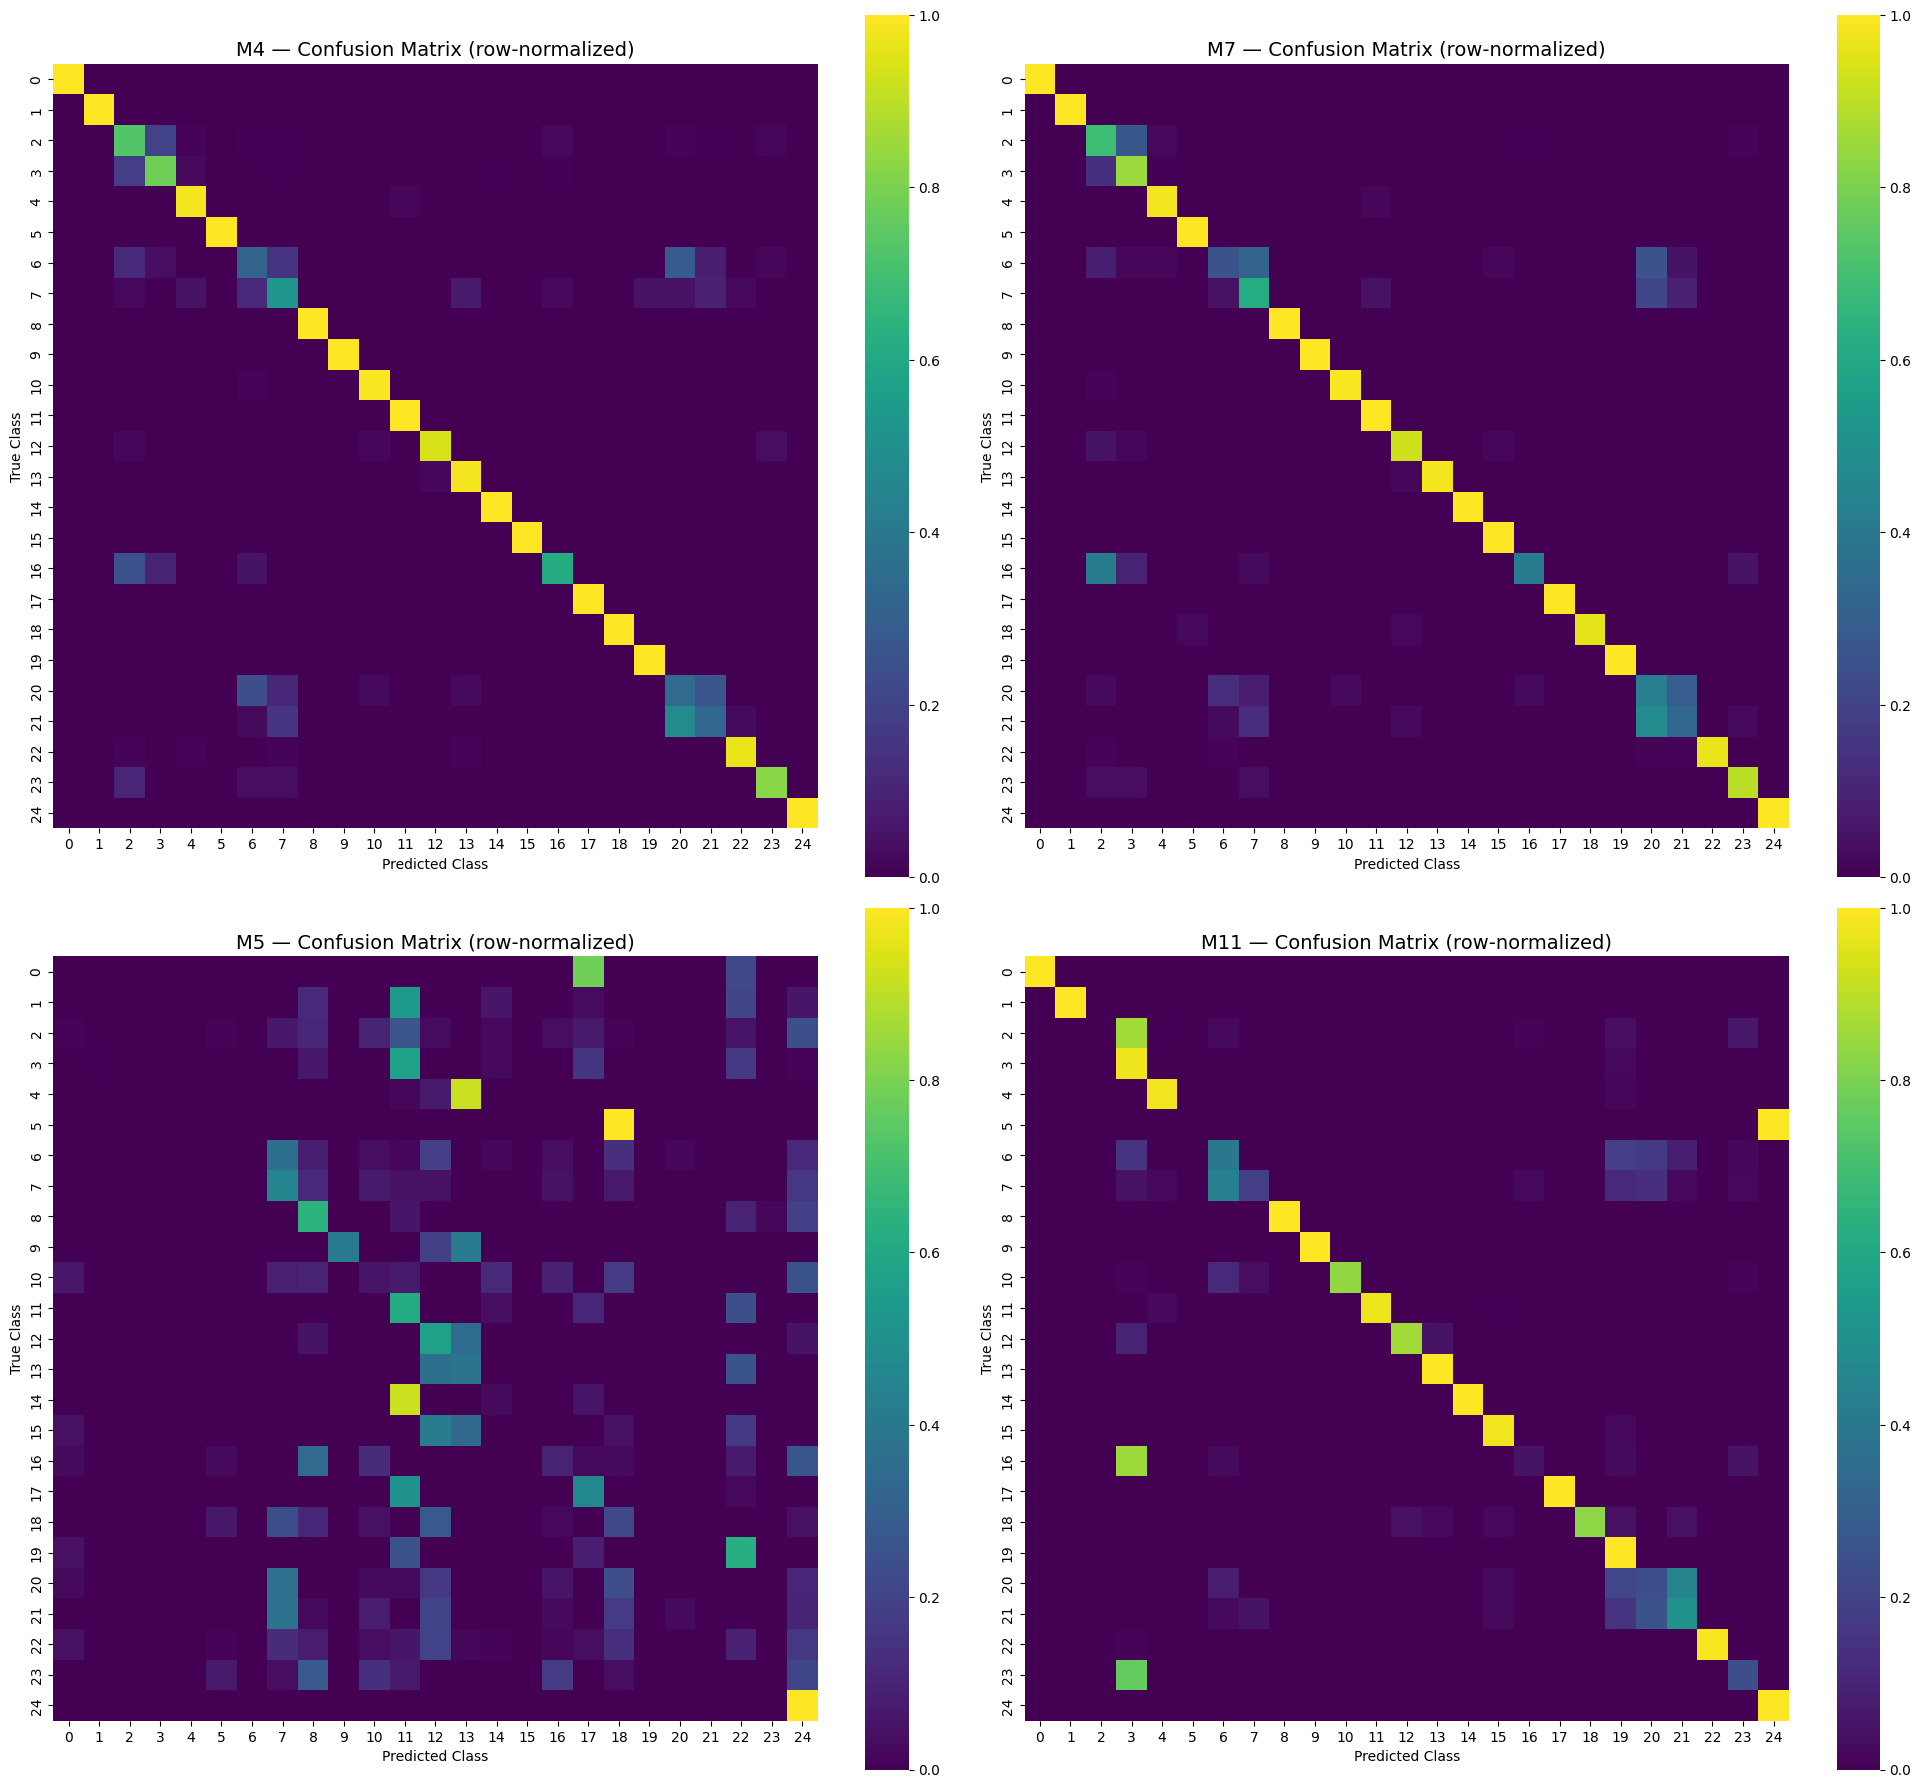

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

selected_models = ['M4', 'M7', 'M5', 'M11']
fig, axes = plt.subplots(2, 2, figsize=(20, 18))
axes = axes.flatten()

for idx, name in enumerate(selected_models):
    model = tf.keras.models.load_model(f'/kaggle/working/checkpoints/{name}_best.keras')
    y_pred = np.argmax(model.predict(X_test_ch, batch_size=64, verbose=0), axis=1)
    cm = confusion_matrix(y_test, y_pred, normalize='true')

    sns.heatmap(cm, annot=False, cmap='viridis', ax=axes[idx], cbar=True,
                vmin=0, vmax=1, square=True)
    axes[idx].set_title(f'{name} — Confusion Matrix (row-normalized)', fontsize=14)
    axes[idx].set_xlabel('Predicted Class')
    axes[idx].set_ylabel('True Class')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
# Check if npz has any label-name mapping we missed
print(data.files)

['arr']


In [51]:
comparison_data = {
    'Model': ['M4 (ours)', 'M7 (ours)', 'M8 (ours)', 'M11 (ours)', 'M12/ResNet50 (ours)',
              'M11 tuned (Pinhero et al., Sec 4.4)'],
    'Architecture': ['Shallow CNN', 'Shallow CNN', 'Shallow CNN', 'VGG3+Dropout+BN', 'ResNet-50',
                      'VGG3+Dropout+BN'],
    'Accuracy (%)': [82.48, 82.05, 78.66, 67.84, 68.42, 98.46],
    'F-measure (%)': [82.61, 82.02, 78.48, 70.50, 65.78, 98.38],
    'Params': ['16.79M', '4.21M', '1.07M', '1.45M', '26.35M', 'Not reported'],
    'Dataset size (train)': [6537]*5 + [15617]  # paper's Malimg+benign 70% split estimate
}

import pandas as pd
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

comparison_df.to_csv('/kaggle/working/paper_comparison.csv', index=False)

latex_table = comparison_df.to_latex(index=False, caption='MalVizNet results vs. Pinhero et al. (2021) Section 4.4',
                                       label='tab:paper_comparison', column_format='llrrrr')
with open('/kaggle/working/paper_comparison.tex', 'w') as f:
    f.write(latex_table)
print("\nLaTeX table saved.")

                              Model    Architecture  Accuracy (%)  F-measure (%)       Params  Dataset size (train)
                          M4 (ours)     Shallow CNN         82.48          82.61       16.79M                  6537
                          M7 (ours)     Shallow CNN         82.05          82.02        4.21M                  6537
                          M8 (ours)     Shallow CNN         78.66          78.48        1.07M                  6537
                         M11 (ours) VGG3+Dropout+BN         67.84          70.50        1.45M                  6537
                M12/ResNet50 (ours)       ResNet-50         68.42          65.78       26.35M                  6537
M11 tuned (Pinhero et al., Sec 4.4) VGG3+Dropout+BN         98.46          98.38 Not reported                 15617

LaTeX table saved.


In [52]:
markdown_table = comparison_df.to_markdown(index=False)
with open('/kaggle/working/paper_comparison.md', 'w') as f:
    f.write(markdown_table)
print(markdown_table)

| Model                               | Architecture    |   Accuracy (%) |   F-measure (%) | Params       |   Dataset size (train) |
|:------------------------------------|:----------------|---------------:|----------------:|:-------------|-----------------------:|
| M4 (ours)                           | Shallow CNN     |          82.48 |           82.61 | 16.79M       |                   6537 |
| M7 (ours)                           | Shallow CNN     |          82.05 |           82.02 | 4.21M        |                   6537 |
| M8 (ours)                           | Shallow CNN     |          78.66 |           78.48 | 1.07M        |                   6537 |
| M11 (ours)                          | VGG3+Dropout+BN |          67.84 |           70.5  | 1.45M        |                   6537 |
| M12/ResNet50 (ours)                 | ResNet-50       |          68.42 |           65.78 | 26.35M       |                   6537 |
| M11 tuned (Pinhero et al., Sec 4.4) | VGG3+Dropout+BN |          98

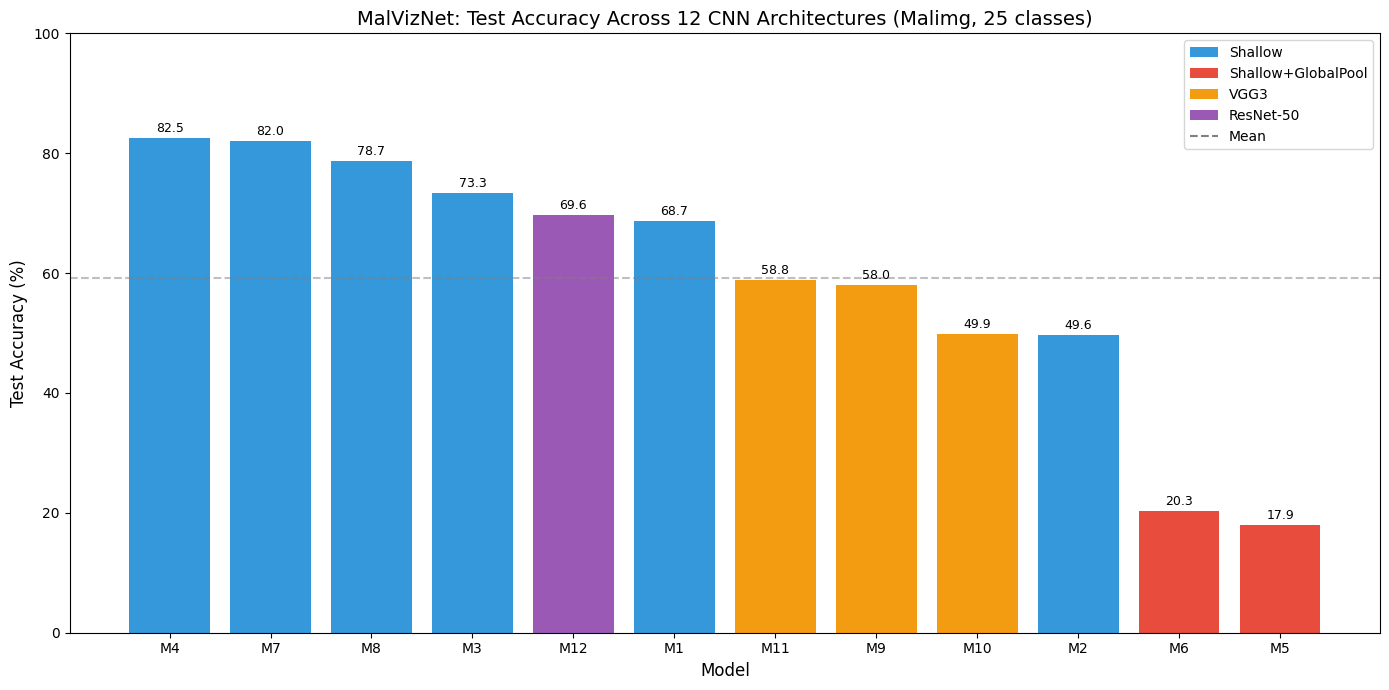

In [53]:
import matplotlib.pyplot as plt

# Use results_df from Cell 21 (already sorted by accuracy)
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#2ecc71' if 'Shallow' not in '' else '#3498db' for _ in results_df['Model']]
# Color by architecture family
arch_map = {
    'M1':'Shallow','M2':'Shallow','M3':'Shallow','M4':'Shallow',
    'M5':'Shallow+GlobalPool','M6':'Shallow+GlobalPool',
    'M7':'Shallow','M8':'Shallow',
    'M9':'VGG3','M10':'VGG3','M11':'VGG3','M12':'ResNet-50'
}
color_scheme = {
    'Shallow':'#3498db', 'Shallow+GlobalPool':'#e74c3c',
    'VGG3':'#f39c12', 'ResNet-50':'#9b59b6'
}
bar_colors = [color_scheme[arch_map[m]] for m in results_df['Model']]

bars = ax.bar(results_df['Model'], results_df['Accuracy']*100, color=bar_colors)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('MalVizNet: Test Accuracy Across 12 CNN Architectures (Malimg, 25 classes)', fontsize=14)
ax.set_ylim(0, 100)
ax.axhline(y=results_df['Accuracy'].mean()*100, color='gray', linestyle='--', alpha=0.5, label=f'Mean: {results_df["Accuracy"].mean()*100:.1f}%')

for bar, acc in zip(bars, results_df['Accuracy']*100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{acc:.1f}', ha='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in color_scheme.items()]
ax.legend(handles=legend_elements + [plt.Line2D([0],[0], color='gray', linestyle='--', label=f'Mean')], loc='upper right')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()